In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import  mean_absolute_error, mean_squared_error,root_mean_squared_error

In [2]:
#import train and test pkl files
train = pd.read_pickle('../models/train_data.pkl')
test = pd.read_pickle('../models/test_data.pkl')

In [3]:
model = ARIMA(train['Passengers'], order=(5,1,0))
model_fit = model.fit()

In [4]:
#forecast the next 12 months
forecast = model_fit.forecast(steps=12)

In [5]:
print("Forecasted values for the next 12 months:")
print(forecast)


Forecasted values for the next 12 months:
132    458.449443
133    479.570529
134    480.136847
135    456.665327
136    435.835309
137    431.734529
138    437.928972
139    448.935482
140    455.562127
141    454.628434
142    450.095384
143    445.706018
Name: predicted_mean, dtype: float64


In [8]:
#actual test values
test_values = test['Passengers'].values
test_values

array([417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432])

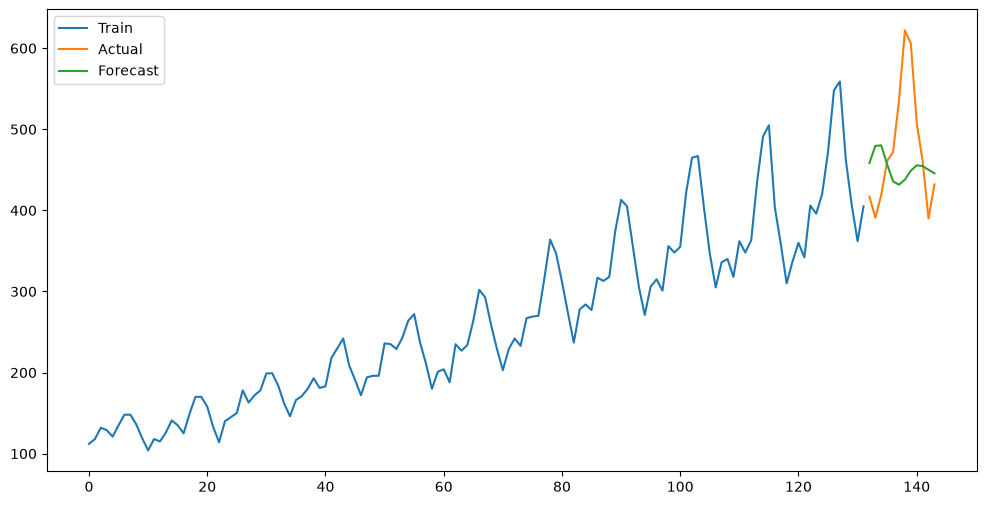

In [9]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.show()

In [12]:
# error metrics
mae = mean_absolute_error(test_values, forecast)
mse = mean_squared_error(test_values, forecast)
rmse = root_mean_squared_error(test_values, forecast)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')


Mean Absolute Error (MAE): 67.38900337470075
Mean Squared Error (MSE): 7535.998692053804
Root Mean Squared Error (RMSE): 86.81013012347006


In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [14]:
train_log = np.log(train['Passengers'])
test_log = np.log(test['Passengers'])


In [15]:
sarima_model = SARIMAX(train_log, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_model_fit = sarima_model.fit(maxiter=200, disp=False)

In [16]:
forecasted_log = sarima_model_fit.forecast(steps=12) 
forecast = np.exp(forecasted_log)


In [17]:
print("Forecasted values for the next 12 months (SARIMA):")
print(forecast)

Forecasted values for the next 12 months (SARIMA):
132    419.908927
133    399.523583
134    466.708698
135    454.426879
136    473.310256
137    548.264548
138    623.169296
139    631.411589
140    526.952867
141    462.509573
142    406.554092
143    451.697027
Name: predicted_mean, dtype: float64


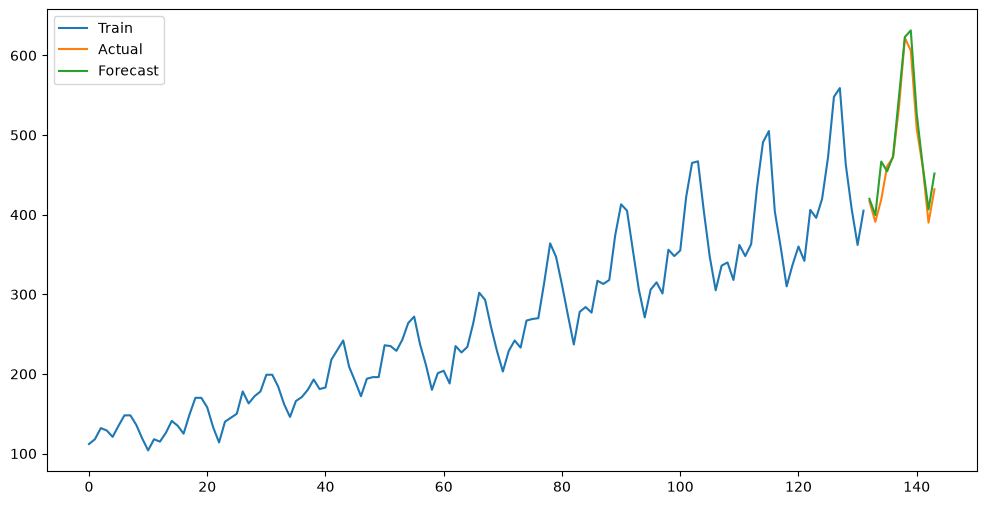

In [18]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label='Train')
plt.plot(test.index, test['Passengers'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.show()

In [19]:
 # error metrics
mae = mean_absolute_error(test_values, forecast)
mse = mean_squared_error(test_values, forecast)
rmse = root_mean_squared_error(test_values, forecast)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')


Mean Absolute Error (MAE): 13.631964699228268
Mean Squared Error (MSE): 354.0600882121391
Root Mean Squared Error (RMSE): 18.81648448069243
